In [1]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib import colors as mcolors

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots will be saved:
paper_plots_dir = '../../paper/images/zero_latency_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


# Everything plotted in this notebook is done using these helper modules
import plotting_utils
from common_utils import get_results_inpainting as get_results, get_results_zero_latency

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
times_before = [0.5, 1, 4, 7, 14]

results_estimate_filtered = get_results(
    f"results/data_runs_psd_estimate.hdf",
    filter_times_before=times_before
)
results_model_filtered = get_results(
    f"results/data_runs_psd_model.hdf",
    filter_times_before=times_before
)

results_estimate_all = get_results(
    f"results/data_runs_psd_estimate.hdf"
)
results_model_all = get_results(
    f"results/data_runs_psd_model.hdf"
)


In [3]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_s = mbhb_sky[0]['CoalescenceTime']

In [4]:
# fig_filtered, _ = plotting_utils.plot_around_time(
#     results_one=results_model_filtered,
#     results_two=results_estimate_filtered,
#     truth_times=truth_times_s,
#     times_before=times_before,
#     label_one='PSD model',
#     label_two='Estimated PSD'
# )
# fig_filtered.savefig(f'plots/signals_results_filtered_by_time.pdf')


In [5]:
# fig_all, _ = plotting_utils.plot_around_time(
#     results_one=results_model_all,
#     results_two=results_estimate_all,
#     truth_times=truth_times_s,
#     times_before=times_before,
#     label_one='PSD model',
#     label_two='Estimated PSD'
# )
# fig_all.savefig(f'plots/signals_results_all_forecast.pdf')

In [6]:
# fig_all, _ = plotting_utils.plot_around_time(
#     results_one=results_model_all,
#     results_two=results_estimate_all,
#     truth_times=truth_times_s,
#     times_before=times_before,
#     label_one='PSD model',
#     label_two='Estimated PSD',
#     predicted_time=False
# )
# fig_all.savefig(f'plots/signals_results_all_end_time.pdf')

In [7]:
# for i, truth_time_s in enumerate(truth_times_s):
#     fig_model, _ = plotting_utils.plot_around_time(
#         results_one=results_model_filtered,
#         results_two=results_estimate_filtered,
#         signal_truth_time=truth_time_s,
#         truth_times=truth_times_s,
#         start_time_offset=-20,
#         end_time_offset=20,
#         times_before=times_before,
#         signal_number=i,
#         label_one='PSD Model',
#         label_two='Estimated PSD'
#     )
#     fig_model.savefig(f'plots/signal_{i}_forecast.pdf')
#     fig_model.show()
    # fig_model.savefig(f'{paper_plots_dir}/psd_model/figure_X_signal_{i}.png', dpi=300)

In [8]:
# for i, truth_time_s in enumerate(truth_times_s):
#     fig_model, _ = plotting_utils.plot_around_time(
#         results_one=results_model_filtered,
#         results_two=results_estimate_filtered,
#         signal_truth_time=truth_time_s,
#         truth_times=truth_times_s,
#         start_time_offset=-20,
#         end_time_offset=20,
#         times_before=times_before,
#         signal_number=i,
#         label_one='PSD Model',
#         label_two='Estimated PSD',
#         predicted_time=False,
#     )
#     fig_model.show()
#     fig_model.savefig(f'plots/signal_{i}_end_time.pdf')
    # fig_model.savefig(f'{paper_plots_dir}/psd_model/figure_X_signal_{i}.png', dpi=300)

In [9]:
# import numpy as np
# from matplotlib import pyplot as plt
# from matplotlib import colors as mcolors
# from matplotlib import cm 

# def calculate_plot_within(
#     results,
#     ax,
#     start_time_offset,
#     end_time_offset,
#     central_time,
#     marker='x',
#     times_before=[0.5,1,4,7,14],
#     alpha=1,
#     predicted_time=True,
#     filter_around_merger=None,
#     color= None,
# ):

#     norm = mcolors.LogNorm(vmin=min(times_before), vmax=max(times_before))
#     used_in_plot = np.ones_like(results['snr'], dtype=bool)
#     # print('Using time' if predicted_time else 'Using data_end_time')
#     result_times = results['time'] if predicted_time else results['data_end_time']

#     # print(result_times)

#     if start_time_offset is not None:
#         used_in_plot = np.logical_and(
#             used_in_plot,
#             ((result_times - central_time) / 86400) >= start_time_offset
#         )

#     if end_time_offset is not None:
#         used_in_plot = np.logical_and(
#             used_in_plot,
#             ((result_times - central_time) / 86400) <= end_time_offset
#         )

#     if filter_around_merger is not None:
#         used_in_plot = np.logical_and(
#             used_in_plot,
#             abs(results['time'] - central_time) < filter_around_merger
#         )

#     if not any(used_in_plot):
#         return 0, None

#     cmap = cm.get_cmap('rainbow')
#     sm = cm.ScalarMappable(norm=norm, cmap=cmap)
#     colors_rgba = sm.to_rgba(results['time_before'][used_in_plot])
#     if color is not None:
#         colors_rgba = 'k'

#     ax.scatter(
#         (result_times[used_in_plot] - central_time) / 86400,
#         results['snr'][used_in_plot],
#         marker=marker,
#         facecolors='none' if marker=='o' else colors_rgba,
#         edgecolors=colors_rgba if marker=='o' else None,
#         alpha=alpha,
#         rasterized=True
#     )

#     return max(results['snr'][used_in_plot]), sm

# def plot_around_time(
#     results_one=None,
#     results_two=None,
#     start_time_offset=20,
#     end_time_offset=370,
#     signal_truth_time=0,
#     signal_number=None,
#     truth_times=None,
#     times_before=[0.5,1,4,7,14],
#     predicted_time=True,
#     label_one='Raw',
#     label_two='Remove',
#     filter_around_merger=None,
#     color_one=None,
#     color_two=None
# ):
#     width = plt.rcParams["figure.figsize"][0] * 1.25
#     height = plt.rcParams["figure.figsize"][1]
#     fig, ax = plt.subplots(1, figsize=(width, height),)

#     max_snr = 0

#     max_snr_one, sm_one = calculate_plot_within(
#         results_one,
#         ax,
#         start_time_offset,
#         end_time_offset,
#         signal_truth_time,
#         marker='x',
#         times_before=times_before,
#         predicted_time=predicted_time,
#         filter_around_merger=filter_around_merger,
#         color=color_one
#     )
#     max_snr = max(max_snr, max_snr_one)

#     if results_two:
#         max_snr_two, sm_two = calculate_plot_within(
#             results_two,
#             ax,
#             start_time_offset,
#             end_time_offset,
#             signal_truth_time,
#             times_before=times_before,
#             marker='o',
#             predicted_time=predicted_time,
#             filter_around_merger=filter_around_merger,
#             color=color_two
#         )
#         max_snr = max(max_snr, max_snr_two)

#     if sm_one is None and sm_two is None:
#         # No results here
#         return fig
#     sm = sm_one if sm_one is not None else sm_two
    
#     # Add pink lines for when the coalescences are:
#     for truth_time_s in truth_times:
#         ax.axvline(
#             (truth_time_s - signal_truth_time) / 86400,
#             c='tab:pink'
#         )

#     # Add lines for when the data ended (if predicted)
#     # when the data predicts (if not)
#     if signal_truth_time != 0:
#         for time_before in times_before:
#             time_to_plot = time_before if predicted_time else -time_before
#             ax.axvline(
#                 time_to_plot,
#                 c=sm.to_rgba(time_before),
#                 linestyle=':'
#             )

#     label_start = "Forecast Merger Time" if predicted_time else "Data End Time"
#     xlab = label_start + " (days)" if signal_truth_time == 0 else label_start + " offset (days)"
#     ax.set_xlabel(xlab)
#     ax.set_ylabel("SNR")
#     cb = fig.colorbar(sm, ax=ax)
#     cb.set_ticks(times_before)
#     cb.set_ticklabels(times_before)

#     lines = []
#     labels = []
#     if results_one:
#         lines.append(ax.scatter([], [], marker='x', facecolors='k', edgecolors=None),)
#         labels.append(label_one)
#     if results_two:
#         lines.append(ax.scatter([], [], marker='o', facecolors='none', edgecolors='k'),)
#         labels.append(label_two)
#     labels.append('Coalescences')
#     lines.append(ax.axvline(np.nan, c='tab:pink'))

#     ax.legend(
#         lines, labels, loc='upper left'
#     )
#     ax.grid()

#     if start_time_offset is not None:
#         ax.set_xlim(left=start_time_offset)
#     if end_time_offset is not None:
#         ax.set_xlim(right=end_time_offset)
        
#     ax.set_ylim(bottom=4)
#     ax.set_ylim(top=max(max_snr * 1.1, 10))
#     if signal_number is not None:
#         ax.set_title(f"Signal {signal_number}: {signal_truth_time:.1f}s")
#     return fig, ax

/local/gareth.cabourndavies/ipykernel_3703370/1188315408.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('rainbow')
/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/matplotlib/transforms.py:2036: RuntimeWarning: invalid value encountered in scalar add
  self._mtx[0, 2] += tx
/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


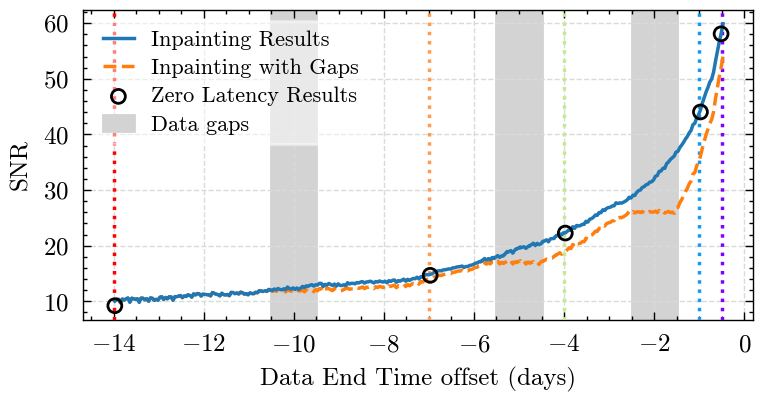

In [32]:
# For signal zero - plot the results filtered so that the predicted time is within an hour of the merger
example_signal = 0

# Get the zero-latency results for this signal
results_zero_latency = get_results_zero_latency(
    "../zero_latency/results/psd_estimate/data_runs_raw_{time_before}_results.hdf",
    times_before
)

# Filter the zero latency results to only use the closest point for each
import numpy as np

zl_results_data_end_time = []
zl_results_snr = []

for t_before in times_before:
    this_t = results_zero_latency['time_before'] == t_before
    closest_match = np.argmin(
        abs(results_zero_latency['time'][this_t] - truth_times_s[example_signal])
    )
    zl_results_data_end_time.append(results_zero_latency['data_end_time'][this_t][closest_match])
    zl_results_snr.append(results_zero_latency['snr'][this_t][closest_match])

zl_results_data_end_time = np.array(zl_results_data_end_time)
zl_results_snr = np.array(zl_results_snr)

width = plt.rcParams["figure.figsize"][0] * 1.25
height = plt.rcParams["figure.figsize"][1]

fig, ax = plt.subplots(1, figsize=(width, height),)


ip_times_before = np.unique(results_estimate_all['time_before'])
ip_results_data_end_time = []
ip_results_snr = []
for t_before in ip_times_before:
    this_t = results_estimate_all['time_before'] == t_before
    closest_match = np.argmin(
        abs(results_estimate_all['time'][this_t] - truth_times_s[example_signal])
    )
    ip_results_data_end_time.append(results_estimate_all['data_end_time'][this_t][closest_match])
    ip_results_snr.append(results_estimate_all['snr'][this_t][closest_match])

inpainting_gaps_results = get_results(
    "results/data_runs_signal_0_gaps.hdf",
)
ipg_times_before = np.unique(inpainting_gaps_results['time_before'])
ipg_results_data_end_time = []
ipg_results_snr = []
for t_before in ip_times_before:
    this_t = inpainting_gaps_results['time_before'] == t_before
    closest_match = np.argmin(
        abs(inpainting_gaps_results['time'][this_t] - truth_times_s[example_signal])
    )
    ipg_results_data_end_time.append(inpainting_gaps_results['data_end_time'][this_t][closest_match])
    ipg_results_snr.append(inpainting_gaps_results['snr'][this_t][closest_match])


ax.plot(
    (ip_results_data_end_time - truth_times_s[example_signal]) / 86400,
    ip_results_snr,
    linewidth=1.25,
    color='tab:blue',
    label='Inpainting Results',
    zorder=10
)
ax.plot(
    (ipg_results_data_end_time - truth_times_s[example_signal]) / 86400,
    ipg_results_snr,
    linewidth=1.25,
    color='tab:orange',
    linestyle='--',
    label='Inpainting with Gaps',
    zorder=8
)

ax.scatter(
    (zl_results_data_end_time - truth_times_s[example_signal]) / 86400,
    zl_results_snr,
    edgecolor='k',
    marker='o',
    facecolors='none',
    label='Zero Latency Results',
    zorder=20

)

norm = mcolors.LogNorm(vmin=min(times_before), vmax=max(times_before))
cmap = cm.get_cmap('rainbow')
sm = cm.ScalarMappable(norm=norm, cmap=cmap)

for time_before in times_before:
    ax.axvline(
        -time_before,
        c=sm.to_rgba(time_before),
        linestyle=':',
        linewidth=1.25,
        zorder=5
    )

for gap in [(2.5, 1.5), (5.5, 4.5), (10.5, 9.5)]:
    ax.axvspan(-gap[0], -gap[1], color='lightgray', zorder=0)
ax.axvspan(-np.inf, -np.inf, color='lightgray', zorder=0, label='Data gaps')

ax.grid(zorder=0)
ax.legend(loc='upper left')
ax.set_ylabel('SNR')
ax.set_xlabel('Data End Time offset (days)')
fig.show()
fig.savefig(f'plots/signal_{example_signal}_end_timeline.pdf')
fig.savefig(f'{paper_plots_dir}/psd_model/figure_X_signal_{example_signal}_timeline.png', dpi=300)